This document is meant to test the discretization invariance of the 2D Fourier neural operator on a heat equation dataset. Unlike the first FNO2D_CDE, this model does not subsample a single larger dataset; initial conditions were generated and subsampled for each wanted resolution, then evolved in time separately to reach different initial conditions.

N= 32 | rel L2 = 2.7827e-01 | std = 1.3147e-02
N= 64 | rel L2 = 1.4611e-01 | std = 8.4963e-03
N=128 | rel L2 = 5.0380e-03 | std = 3.1621e-04
N=256 | rel L2 = 8.8614e-02 | std = 4.6076e-03
N=512 | rel L2 = 1.2101e-01 | std = 6.4674e-03


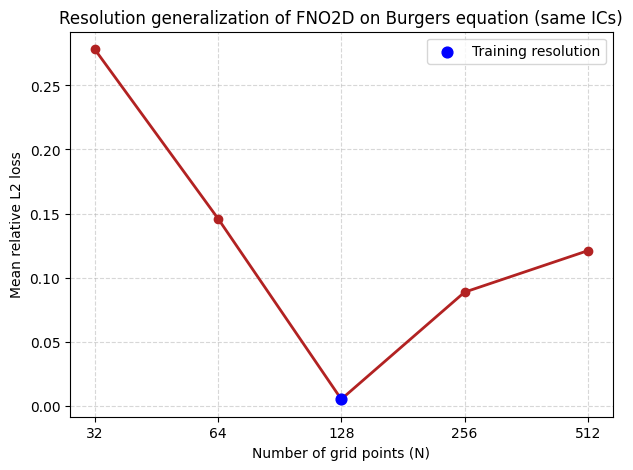

In [17]:
import glob
import torch
import numpy as np
import h5py
from torch.utils.data import DataLoader, TensorDataset
from FNO2D_def import *
from CDE_helper import *

modes1 = modes2 = 16
width = 128
model_path = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_multi128_2.pt"
dataset = "u"
device = "cuda:1" if torch.cuda.is_available() else "cpu"

model = FNO2D(modes1, modes2, width)
model.q = torch.nn.Conv2d(width, 1, 1)  # same as in your training script
model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()

def evaluate_dataset(model, h5_path, batch_size=4, device = "cuda:0"):
    """Evaluate (ω0 → ωT) mapping on a multi-resolution NS dataset file."""
    with h5py.File(h5_path, "r") as f:
        omega = f[dataset][:]   # shape (B,2,N,N)


    ω0 = torch.tensor(omega[:,0], dtype=torch.float32)[:,None]  # (B,1,N,N)
    ωT = torch.tensor(omega[:,1], dtype=torch.float32)[:,None]

    loader = DataLoader(
        TensorDataset(ω0, ωT),
        batch_size=batch_size,
        shuffle=False
    )

    losses = []
    model.eval()
    with torch.no_grad():
        for ω_in, ω_out in loader:
            ω_in = ω_in.to(device)
            ω_out = ω_out.to(device)

            pred = model(ω_in.permute(0,2,3,1))
            pred = pred.permute(0,3,1,2)

            losses.append(relative_l2(pred, ω_out))

    return float(np.mean(losses)), float(np.std(losses)), ω0.shape[-1]


# ----------------- RUN CDE TEST -----------------

model.eval()
folder = "/scratch/mnhagen/datasets/heat2d_multires/"
paths = sorted(
    glob.glob(folder + "heat2D_autoreg_N*_multi.h5"),
    key=lambda p: int(p.split("_autoreg_N")[1].split("_")[0])
)

resolutions = []
for p in paths:
    resolutions.append(int(p.split("_autoreg_N")[1].split("_")[0]))

model_path = "/scratch/mnhagen/models/heat2d/FNO2D_heat2d_multi128.pt"
train_N = int(model_path.split("_multi")[1].split(".pt")[0])

results = []

for p in paths:
    mean_rel, std_rel, N_eval = evaluate_dataset(model, p, batch_size=4, device = device)
    print(f"N={N_eval:3d} | rel L2 = {mean_rel:.4e} | std = {std_rel:.4e}")
    results.append((N_eval, mean_rel, std_rel))

# List of means if needed
means = [m for (_, m, _) in results]


plt.figure(figsize=(7,5))
plt.plot(resolutions, means, 'o-', color="firebrick", lw=2)

for i in range(len(resolutions)):
    if resolutions[i] == train_N:
        plt.scatter(resolutions[i], means[i], color='blue', s=60, zorder=5, label='Training resolution')

plt.xscale('log', base=2)
#plt.yscale('log', base = 10)
plt.xticks(resolutions, [str(r) for r in resolutions])
plt.xlabel("Number of grid points (N)")
plt.ylabel("Mean relative L2 loss")
plt.title("Resolution generalization of FNO2D on Burgers equation (same ICs)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

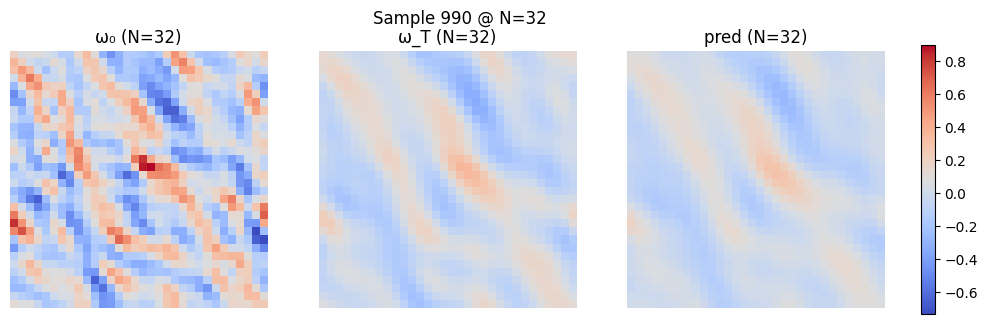

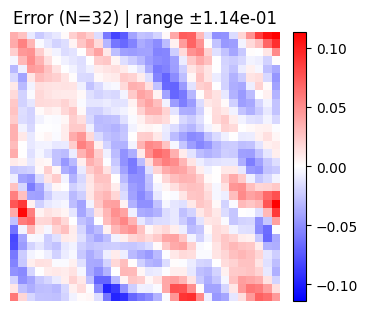

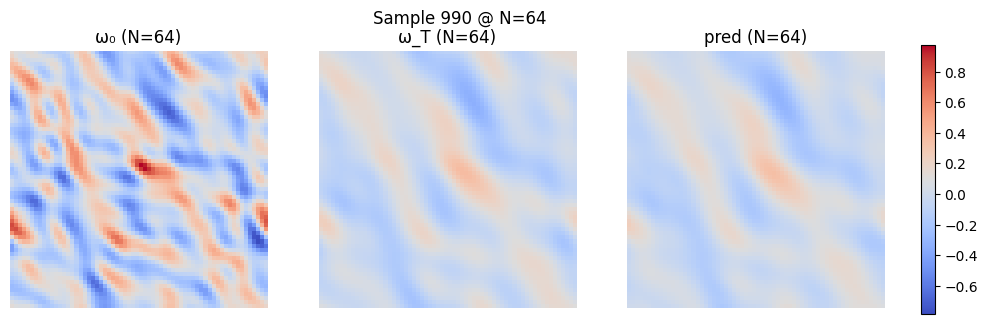

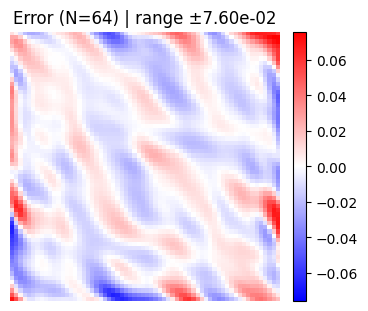

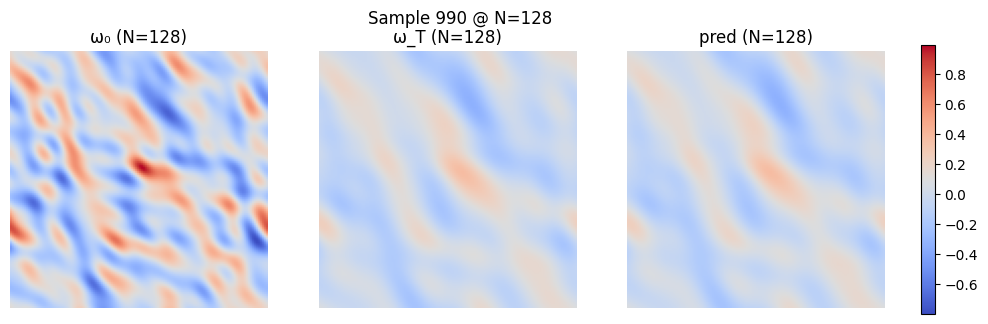

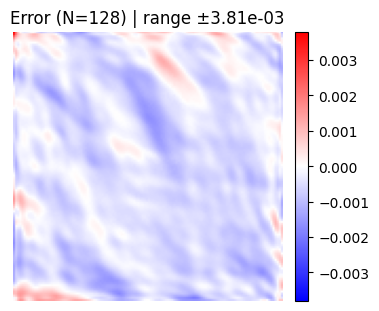

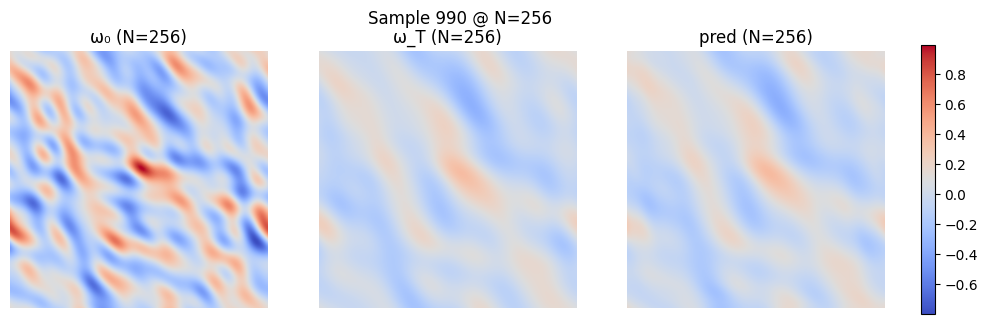

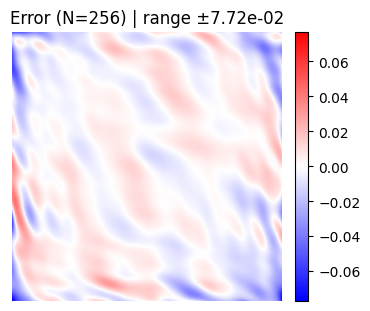

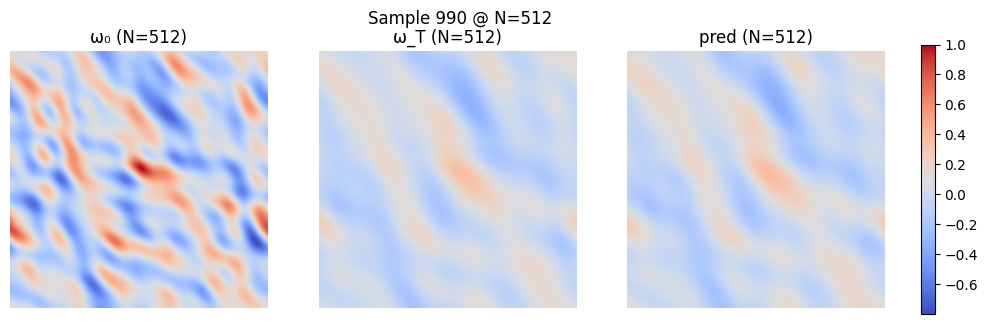

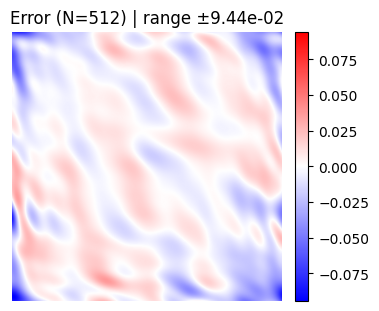

In [18]:
import matplotlib.pyplot as plt

sample_idx = 990

def plot_across_resolutions(model, folder, sample_idx, device="cuda:0", PDE = "heat2D"):
    # find dataset files
    paths = sorted(
    glob.glob(folder + "heat2D_autoreg_N*_multi.h5"),
    key=lambda p: int(p.split("_autoreg_N")[1].split("_")[0])
)

    model.eval()

    for p in paths:
        with h5py.File(p, "r") as f:
            omega = f[dataset][:]   # (num_samples,2,N,N)

        ω0 = omega[sample_idx,0]   # (N,N)
        ωT = omega[sample_idx,1]
        N = ω0.shape[0]

        # Format for model
        ω_in = torch.tensor(ω0[None,None], dtype=torch.float32).to(device)
        with torch.no_grad():
            pred = model(ω_in.permute(0,2,3,1)).permute(0,3,1,2)[0,0].cpu().numpy()

        u0_np  = ω0
        uT_np  = ωT
        pr_np  = pred
        diff   = uT_np - pr_np

        vmin = min(u0_np.min(), uT_np.min(), pr_np.min())
        vmax = max(u0_np.max(), uT_np.max(), pr_np.max())

        fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
        for ax, arr, ttl in zip(
            axes,
            [u0_np, uT_np, pr_np],
            [f"ω₀ (N={N})", f"ω_T (N={N})", f"pred (N={N})"]
        ):
            im = ax.imshow(arr, cmap="coolwarm", origin="lower",
                           vmin=vmin, vmax=vmax)
            ax.set_title(ttl); ax.axis("off")
        fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
        plt.suptitle(f"Sample {sample_idx} @ N={N}")
        plt.show()

        # difference plot
        m = np.abs(diff).max()
        plt.figure(figsize=(4.2, 3.5))
        plt.imshow(diff, cmap="bwr", origin="lower",
                   vmin=-m, vmax=m)
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.title(f"Error (N={N}) | range ±{m:.2e}")
        plt.axis("off")
        plt.show()


# ----------------- RUN PLOT -----------------

plot_across_resolutions(
    model,
    folder="/scratch/mnhagen/datasets/heat2d_multires/",
    sample_idx=sample_idx,
    device=device
)
